### Phase 3: Customer Lifetime Value (LTV) Modeling & Pipeline Bridge
**Dataset:** `online_retail_II.csv` (Transactional Data) & `marketing_AB.csv` (Top-of-Funnel Data)

## Objectives
1. **RFM Feature Engineering:** Transform raw transaction logs into Recency, Frequency, and Monetary (RFM) matrices.
2. **Probabilistic Modeling:** Train a BG/NBD model to predict future purchase volume and a Gamma-Gamma model to predict average order value.
3. **The Pipeline Bridge (Simulation):** Resolve identities by mapping top-of-funnel marketing conversions to bottom-of-funnel customer profiles.
4. **Campaign ROI:** Calculate the true projected 90-day revenue generated by the Ad vs. PSA campaigns.
5. **Customer Segmentation (K-Means):** Cluster the customer base into actionable business personas based on their behaviors and predicted value.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
np.random.seed(42)

#### Data Cleaning & RFM Engineering
We load the retail transactions, remove cancellations and missing customer IDs, and aggregate the raw logs into a customer-level RFM matrix.

In [2]:
# Load Data
retail_df = pd.read_csv('../data/online_retail_II.csv')

# Display first rows
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Drop rows without Customer IDs, remove cancelled orders (Quantity < 0), and free items (Price = 0)
retail_df = retail_df.dropna(subset=['Customer ID'])
retail_df = retail_df[(retail_df['Quantity'] > 0) & (retail_df['Price'] > 0)]

# Calculate total sales per row
retail_df['TotalSales'] = retail_df['Quantity'] * retail_df['Price']
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

print(f"Cleaned Transactions: {len(retail_df)}")
print(f"Unique Customers: {retail_df['Customer ID'].nunique()}")

Cleaned Transactions: 805549
Unique Customers: 5878


In [4]:
# Create RFM Summary Matrix using lifetimes utility
rfm_df = summary_data_from_transaction_data(
    transactions=retail_df,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalSales',
    observation_period_end=retail_df['InvoiceDate'].max()
)

# Gamma-Gamma requires Frequency > 0 (Returning customers only)
rfm_df = rfm_df[rfm_df['frequency'] > 0]

print(f"\nEligible Customers for LTV Modeling (Repeat Buyers): {len(rfm_df)}")
display(rfm_df.head())


Eligible Customers for LTV Modeling (Repeat Buyers): 4189


,frequency,recency,T,monetary_value
Customer ID,,,,
12346.0,7.0,400.0,725.0,11066.637143
12347.0,7.0,402.0,404.0,717.398571
12348.0,4.0,363.0,438.0,449.310000
12349.0,3.0,571.0,589.0,1120.056667
12352.0,8.0,356.0,392.0,338.261250


#### 3.2 Probabilistic LTV Modeling
We apply the **BG/NBD (Beta-Geometric/Negative Binomial Distribution)** model to predict *how many* purchases a customer will make in the next 90 days. Then, we use the **Gamma-Gamma** model to predict *how much* they will spend per transaction.

**Step 1 — BG/NBD Model (Predicts Future Transactions)**

This model answers: *"How many times will this customer buy in the next 90 days?"*

It works by learning two things from each customer's history:
- **How often** they purchased in the past (their transaction rate)
- **Whether they have churned** (dropped off and stopped buying)

It uses three RFM inputs: `frequency` (past purchase count), `recency` (days since last purchase), and `T` (total observation window in days).

In [5]:
# Fit the BG/NBD Model (Predicts Future Transactions)
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(rfm_df['frequency'], rfm_df['recency'], rfm_df['T'])

# Predict number of purchases in the next 90 days
t_days = 90
rfm_df['predicted_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t_days, rfm_df['frequency'], rfm_df['recency'], rfm_df['T']
)

**Step 2 — Gamma-Gamma Model (Predicts Monetary Value)**

This model answers: *"How much will this customer spend per transaction?"*

It predicts the expected average order value for each customer based on their past spend history. 

**Key assumption:** Purchase frequency and monetary value must be independent of each other. We verify this with a correlation check — if the correlation is close to 0, the assumption holds and we can safely use this model.

In [6]:
# Fit the Gamma-Gamma Model (Predicts Monetary Value)
corr_matrix = rfm_df[['frequency', 'monetary_value']].corr()
print(f"Pearson Correlation (Freq vs Monetary): {corr_matrix.iloc[0,1]:.3f} (Valid if close to 0)\n")

ggf = GammaGammaFitter(penalizer_coef=0.0)
ggf.fit(rfm_df['frequency'], rfm_df['monetary_value'])

# Predict expected average order value
rfm_df['predicted_aov'] = ggf.conditional_expected_average_profit(
    rfm_df['frequency'], rfm_df['monetary_value']
)

Pearson Correlation (Freq vs Monetary): 0.023 (Valid if close to 0)



**Step 3 — Combine Both Models  (90-Day CLV)**

We now combine both models to get a single **Customer Lifetime Value (CLV)** score per customer over a 90-day horizon:

> `CLV = predicted transactions × predicted average order value × discount factor`

The `discount_rate=0.01` is a monthly discount rate that accounts for the time value of money — a purchase today is worth slightly more than one in 3 months.

In [7]:
# Calculate 90-Day CLV by combining BG/NBD + Gamma-Gamma
rfm_df['predicted_clv_90d'] = ggf.customer_lifetime_value(
    bgf,
    rfm_df['frequency'],
    rfm_df['recency'],
    rfm_df['T'],
    rfm_df['monetary_value'],
    time=90,          # 90-day prediction horizon
    freq='D',         # time unit is days
    discount_rate=0.01
)

print("Sample LTV Predictions :")
display(rfm_df[['frequency', 'monetary_value', 'predicted_purchases_90d', 'predicted_clv_90d']].sort_values(by='predicted_clv_90d', ascending=False).head())

Sample LTV Predictions :


,frequency,monetary_value,predicted_purchases_90d,predicted_clv_90d
Customer ID,,,,
18102.0,66.0,9189.930455,7.162533,1.181768e+06
14646.0,90.0,5809.905333,9.722359,1.019255e+06
16446.0,1.0,168469.600000,0.659786,8.530833e+05
17450.0,30.0,6924.523000,5.157345,6.142599e+05
14156.0,120.0,2607.329750,12.869008,6.079501e+05


#### 3.3 The Pipeline Bridge (Identity Resolution Simulation)
The top-of-funnel marketing dataset and the bottom-of-funnel retail dataset do not share a foreign key. To test our end-to-end pipeline, we build an **Identity Resolution Simulator**.

We randomly assign every user who converted in the A/B test to an LTV profile from our retail customer database. This simulates how real companies stitch ad-click data to purchase histories using hashed emails or device matching.

**Why random assignment is valid here:** We are not trying to show that one group has higher LTV — we are testing whether our pipeline can project revenue for any converted user. The random mapping preserves the real LTV distribution from the retail data.

In [8]:
# Load top-of-funnel marketing converters
marketing_df = pd.read_csv('../data/marketing_data.csv', index_col=0)
converters = marketing_df[marketing_df['converted'] == True].copy()

# Get the list of retail Customer IDs with LTV profiles
ltv_profiles = rfm_df.index.tolist()

print(f"Converters to map: {len(converters):,}")
print(f"Retail LTV profiles available: {len(ltv_profiles):,}")

Converters to map: 14,843
Retail LTV profiles available: 4,189


In [ ]:
# Identity Resolution Simulation — Pure Random Assignment
def assign_ltv_profile(group):
    return np.random.choice(ltv_profiles)

In [10]:
# Apply mapping
converters['mapped_customer_id'] = converters['test group'].apply(assign_ltv_profile)

# Merge LTV predictions onto the marketing data
bridge_df = converters.merge(
    rfm_df[['predicted_clv_90d']],
    left_on='mapped_customer_id',
    right_index=True,
    how='left'
)

print("Bridge Successful: Marketing Conversions mapped to 90-Day LTV profiles.")
display(bridge_df[['user id', 'test group', 'mapped_customer_id', 'predicted_clv_90d']].head())

Bridge Successful: Marketing Conversions mapped to 90-Day LTV profiles.


,user id,test group,mapped_customer_id,predicted_clv_90d
15,1461774,ad,13582.0,983.960431
44,1355531,ad,17651.0,15138.527515
107,1389878,ad,16711.0,5959.169539
121,1475989,ad,13019.0,1453.531256
135,1241733,ad,17193.0,5428.152114


#### 3.4 True Campaign ROI & Business Value
Instead of evaluating the campaign strictly on "cost per click" or "conversion volume", we can now evaluate the actual financial return over a 90-day horizon based on our probabilistic models.

In [11]:
# Calculate financial metrics per group
roi_summary = bridge_df.groupby('test group').agg(
    total_conversions=('user id', 'count'),
    avg_predicted_clv=('predicted_clv_90d', 'mean'),
    total_projected_revenue_90d=('predicted_clv_90d', 'sum')
)

roi_summary = roi_summary.reindex(['ad', 'psa'])
display(roi_summary.style.format({
    'total_conversions': '{:,}',
    'avg_predicted_clv': '${:,.2f}',
    'total_projected_revenue_90d': '${:,.2f}'
}))

,total_conversions,avg_predicted_clv,total_projected_revenue_90d
test group,,,
ad,"14,423","$8,917.15","$128,611,989.12"
psa,420,"$12,559.74","$5,275,090.09"


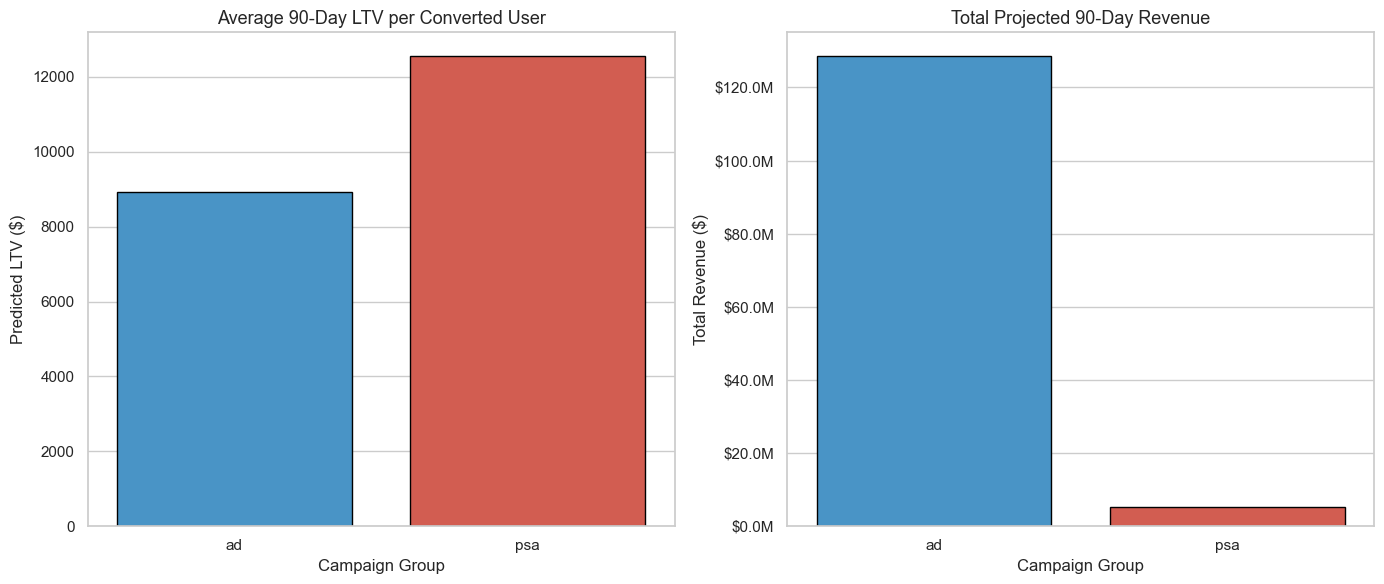

In [12]:
# Visualizing the True Value
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Average CLV per User
sns.barplot(
    data=roi_summary.reset_index(),
    x='test group',
    y='avg_predicted_clv',
    ax=axes[0],
    palette=['#3498db', '#e74c3c'],
    edgecolor='black'
)
axes[0].set_title('Average 90-Day LTV per Converted User', fontsize=13)
axes[0].set_ylabel('Predicted LTV ($)')
axes[0].set_xlabel('Campaign Group')

# Plot 2: Total Projected Revenue
sns.barplot(
    data=roi_summary.reset_index(),
    x='test group',
    y='total_projected_revenue_90d',
    ax=axes[1],
    palette=['#3498db', '#e74c3c'],
    edgecolor='black'
)
axes[1].set_title('Total Projected 90-Day Revenue', fontsize=13)
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_xlabel('Campaign Group')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:,.1f}M'))

plt.tight_layout()
plt.show()

#### 3.5 Machine Learning Customer Segmentation (K-Means)
To make our LTV predictions actionable for the marketing team, we will cluster our customers into distinct personas using the **K-Means** algorithm.

* **Feature Engineering:** RFM data is naturally right-skewed (a few people spend a lot, most spend a little). We apply a Logarithmic Transformation `log(x+1)` to normalize the distribution, followed by a `StandardScaler` so that Recency (Days) and Monetary Value (Dollars) are weighted equally by the algorithm.
* **Choosing K:** We use the **Elbow Method** — plot the inertia (within-cluster variance) for different values of K and pick the point where improvement starts to flatten.
* **Target Segments:** We will divide the audience into 4 distinct groups and evaluate their average 90-Day LTV.

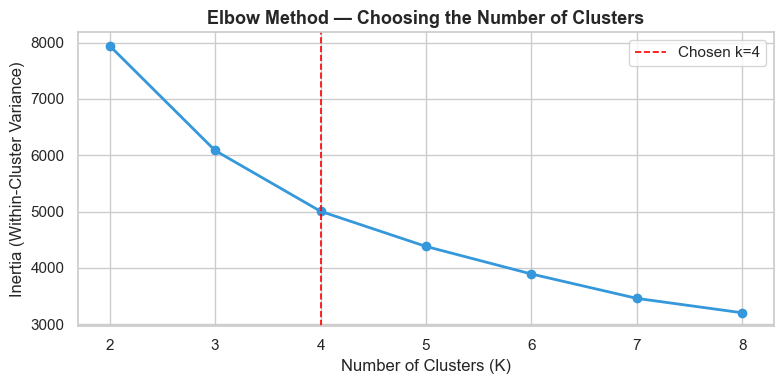

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Feature Pre-processing (Log Transform + Scaling)
features = ['recency', 'frequency', 'monetary_value']
X = rfm_df[features].copy()

for col in features:
    X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method — find the optimal number of clusters
inertia = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='#3498db', linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', linewidth=1.2, label='Chosen k=4')
plt.title('Elbow Method — Choosing the Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Variance)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Fit K-Means Model with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyze and Name the Clusters
cluster_summary = rfm_df.groupby('Cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary_value': 'mean',
    'predicted_clv_90d': ['mean', 'count']
}).reset_index()

# Flatten the multi-level columns
cluster_summary.columns = ['Cluster', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Avg_90D_LTV', 'Customer_Count']

# Sort clusters by their value (LTV) to assign logical names
cluster_summary = cluster_summary.sort_values(by='Avg_90D_LTV', ascending=False).reset_index(drop=True)

# Assign business names based on rank
persona_names = {
    cluster_summary.loc[0, 'Cluster']: "1. Champions (High Spend, High Freq)",
    cluster_summary.loc[1, 'Cluster']: "2. Loyal Spenders (Steady Revenue)",
    cluster_summary.loc[2, 'Cluster']: "3. Promising/Recent (Low Freq, High Potential)",
    cluster_summary.loc[3, 'Cluster']: "4. At-Risk/Low Value (Old Recency, Low Spend)"
}

rfm_df['Persona'] = rfm_df['Cluster'].map(persona_names)

print("Segment Characteristics:")
display(cluster_summary.style.format({
    'Avg_Recency': '{:.1f} days',
    'Avg_Frequency': '{:.1f} times',
    'Avg_Monetary': '${:.2f}',
    'Avg_90D_LTV': '${:.2f}',
    'Customer_Count': '{:,} users'
}))

Segment Characteristics:


,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_90D_LTV,Customer_Count
0,1,603.1 days,16.0 times,$502.70,$21652.31,"1,201 users"
1,0,360.2 days,2.9 times,$763.55,$6417.81,"1,175 users"
2,2,54.4 days,1.5 times,$260.15,$4097.82,675 users
3,3,371.4 days,3.2 times,$174.75,$2648.48,"1,138 users"


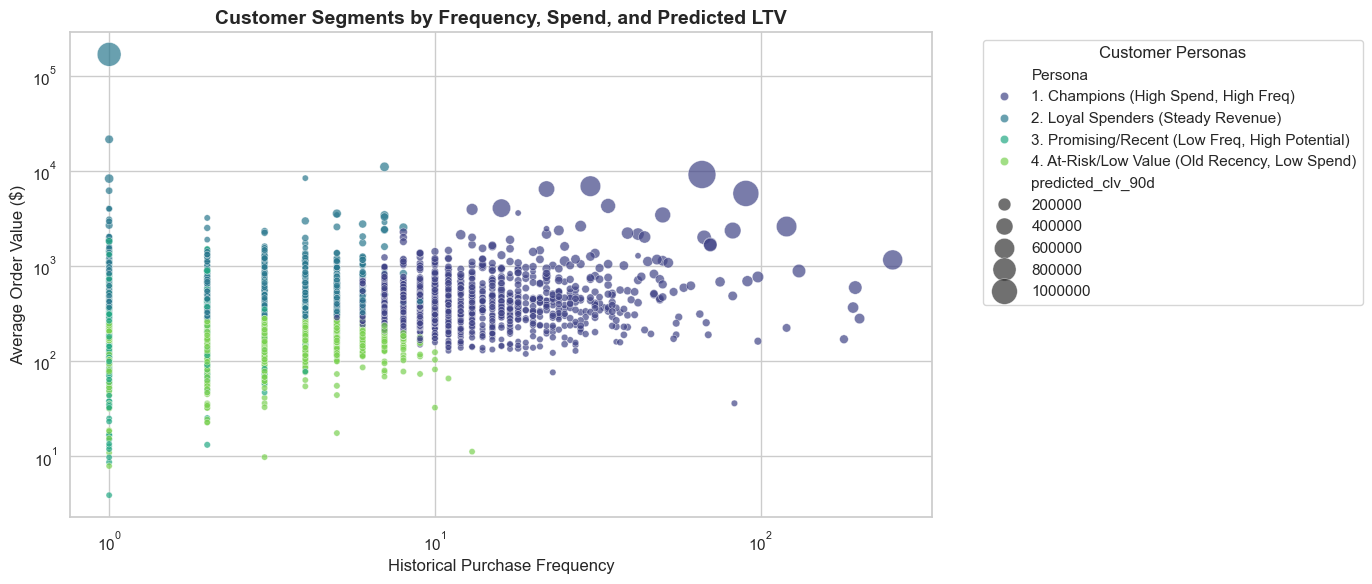

In [ ]:
# Visualizing the Persona
plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=rfm_df,
    x='frequency',
    y='monetary_value',
    hue='Persona',
    palette='viridis',
    size='predicted_clv_90d',
    sizes=(20, 400),
    alpha=0.7,
    hue_order=sorted(rfm_df['Persona'].unique())
)

plt.title('Customer Segments by Frequency, Spend, and Predicted LTV', fontsize=14, fontweight='bold')
plt.xlabel('Historical Purchase Frequency', fontsize=12)
plt.ylabel('Average Order Value ($)', fontsize=12)

# Set axes to log scale to make the visual cleaner (handles extreme outliers)
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Customer Personas")

plt.tight_layout()
plt.show()

In [ ]:
# Export data
import os
os.makedirs('../data', exist_ok=True)

# Save the RFM profiles and Segments
rfm_df.to_csv('../data/final_rfm_data.csv')

# Save the Pipeline Bridge (Marketing + LTV)
bridge_df.to_csv('../data/final_bridge_data.csv')

#### Conclusion
We proved not only that the Ad campaign drives more top-of-funnel volume, but that we can dynamically project the bottom-of-funnel financial impact of those users over the next quarter, enabling Value-Based Bidding strategies for future marketing spend.